# Phase 4: Data Preprocessing and Model Building

Before training machine learning models, the dataset must be preprocessed to ensure it is in a suitable numerical format. This includes separating the features and target variable, encoding categorical variables, and splitting the data into training and testing sets.

In [151]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [152]:
df = pd.read_csv("../dataset/cleaned_house_price_dataset.csv")

## Feature Selection

Machine learning models require a clear distinction between the input features (independent variables) and the target variable (dependent variable).

In this project:

- **Features (X):** Property characteristics used for prediction.
- **Target (y):** House price.

In [153]:
X = df.drop(columns=["PRICE"])
y = df["PRICE"]

In [154]:
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (2392, 21)
Target Shape   : (2392,)


In [155]:
X.head()

,LOCATION,LAND AREA,ROAD ACCESS,FACING,FLOOR,BEDROOM,BATHROOM,PROPERTY_TYPE,HOUSE AGE,PARKING_SPACES,...,BALCONY,GARDEN,DRAINAGE,DRINKING_WATER,EARTHQUAKE_RESISTANT,MODULAR_KITCHEN,LIVING_ROOM,DINING_ROOM,POWER_BACKUP,AMENITIES_COUNT
0,"Imadol, Lalitpur",1369.000,12.0,WEST,3.0,5.0,4.0,House,7.0,1,...,0,0,0,1,1,1,0,1,0,11
1,"Satdobato, Lalitpur",1026.750,10.0,WEST,4.5,5.0,6.0,House,7.0,2,...,0,0,0,1,1,1,0,1,0,11
2,"Imadol, Lalitpur",787.175,10.0,WEST,2.5,4.0,4.0,House,23.0,1,...,1,0,0,1,1,1,0,1,0,11
3,"Bhaisepati, Lalitpur",2395.750,12.0,NORTH-WEST,2.5,4.0,3.0,Bungalow,24.0,4,...,1,1,0,1,1,1,0,0,0,11
4,"Bhaisepati, Lalitpur",1095.200,13.0,NORTH-WEST,2.5,4.0,3.0,House,9.0,4,...,0,0,0,1,1,0,0,0,0,11


In [156]:
X.dtypes

LOCATION                    str
LAND AREA               float64
ROAD ACCESS             float64
FACING                      str
FLOOR                   float64
BEDROOM                 float64
BATHROOM                float64
PROPERTY_TYPE               str
HOUSE AGE               float64
PARKING_SPACES            int64
PARKING                   int64
BALCONY                   int64
GARDEN                    int64
DRAINAGE                  int64
DRINKING_WATER            int64
EARTHQUAKE_RESISTANT      int64
MODULAR_KITCHEN           int64
LIVING_ROOM               int64
DINING_ROOM               int64
POWER_BACKUP              int64
AMENITIES_COUNT           int64
dtype: object

## Train Test Split

We split our data into two parts:
- Training data: Used to teach the model
- Testing data: Used to check how well the model performs on unseen data

In [157]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [158]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1913, 21)
(479, 21)
(1913,)
(479,)


In [159]:
X_train.dtypes

LOCATION                    str
LAND AREA               float64
ROAD ACCESS             float64
FACING                      str
FLOOR                   float64
BEDROOM                 float64
BATHROOM                float64
PROPERTY_TYPE               str
HOUSE AGE               float64
PARKING_SPACES            int64
PARKING                   int64
BALCONY                   int64
GARDEN                    int64
DRAINAGE                  int64
DRINKING_WATER            int64
EARTHQUAKE_RESISTANT      int64
MODULAR_KITCHEN           int64
LIVING_ROOM               int64
DINING_ROOM               int64
POWER_BACKUP              int64
AMENITIES_COUNT           int64
dtype: object

## Separating Numerical and Categorical Features

Machine learning models understand numbers only.
We will encode categorical columns and keep numerical columns unchanged.

In [160]:
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

Categorical Columns:
Index(['LOCATION', 'FACING', 'PROPERTY_TYPE'], dtype='str')

Numerical Columns:
Index(['LAND AREA', 'ROAD ACCESS', 'FLOOR', 'BEDROOM', 'BATHROOM', 'HOUSE AGE',
       'PARKING_SPACES', 'PARKING', 'BALCONY', 'GARDEN', 'DRAINAGE',
       'DRINKING_WATER', 'EARTHQUAKE_RESISTANT', 'MODULAR_KITCHEN',
       'LIVING_ROOM', 'DINING_ROOM', 'POWER_BACKUP', 'AMENITIES_COUNT'],
      dtype='str')


In [161]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

In [162]:
X_train.isnull().sum()

LOCATION                0
LAND AREA               0
ROAD ACCESS             0
FACING                  0
FLOOR                   0
BEDROOM                 0
BATHROOM                0
PROPERTY_TYPE           0
HOUSE AGE               0
PARKING_SPACES          0
PARKING                 0
BALCONY                 0
GARDEN                  0
DRAINAGE                0
DRINKING_WATER          0
EARTHQUAKE_RESISTANT    0
MODULAR_KITCHEN         0
LIVING_ROOM             0
DINING_ROOM             0
POWER_BACKUP            0
AMENITIES_COUNT         0
dtype: int64

In [163]:
model = LinearRegression()

In [164]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [165]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['LOCATION','LAND AREA','ROAD ACCESS',...,'DINING_ROOM','POWER_BACKUP', 'AMENITIES_COUNT']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subs

In [166]:
y_pred = pipe.predict(X_test)

In [167]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 11120024.156629449
R2 Score: 0.320829825508967


## Random Forest Regression

Random Forest is a tree-based model.
It can capture complex relationships in house prices better than Linear Regression.

In [168]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [169]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

In [170]:
rf_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['LOCATION','LAND AREA','ROAD ACCESS',...,'DINING_ROOM','POWER_BACKUP', 'AMENITIES_COUNT']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subs

In [171]:
rf_pred = rf_pipe.predict(X_test)

In [172]:
print("Random Forest Results")

print("MAE:", mean_absolute_error(y_test, rf_pred))

print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results
MAE: 8986341.77850681
R2 Score: 0.5143656169649331


In [173]:
feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()

feature_names

array(['categorical__LOCATION_Bafal, Kathmandu',
       'categorical__LOCATION_Baluwakhani, Kathmandu',
       'categorical__LOCATION_Baluwatar, Kathmandu',
       'categorical__LOCATION_Banasthali, Kathmandu',
       'categorical__LOCATION_Bansbari, Kathmandu',
       'categorical__LOCATION_Bhaisepati, Lalitpur',
       'categorical__LOCATION_Bhangal, Kathmandu',
       'categorical__LOCATION_Budhanilkantha, Kathmandu',
       'categorical__LOCATION_Chandragiri, Kathmandu',
       'categorical__LOCATION_Chunikhel, Kathmandu',
       'categorical__LOCATION_Deuwa Chowk, Kathmandu',
       'categorical__LOCATION_Dhapakhel, Lalitpur',
       'categorical__LOCATION_Dhapasi, Kathmandu',
       'categorical__LOCATION_Ganesh Chowk, Kathmandu',
       'categorical__LOCATION_Goldhunga, Kathmandu',
       'categorical__LOCATION_Golfutar, Kathmandu',
       'categorical__LOCATION_Gongabu, Kathmandu',
       'categorical__LOCATION_Gothatar, Kathmandu',
       'categorical__LOCATION_Gwarko, Lalitpu

In [174]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
66,remainder__LAND AREA,0.599157
70,remainder__BATHROOM,0.039672
71,remainder__HOUSE AGE,0.035928
67,remainder__ROAD ACCESS,0.032467
83,remainder__AMENITIES_COUNT,0.030092
5,"categorical__LOCATION_Bhaisepati, Lalitpur",0.029038
69,remainder__BEDROOM,0.028956
32,"categorical__LOCATION_Nagarjung, Kathmandu",0.026759
68,remainder__FLOOR,0.023597
82,remainder__POWER_BACKUP,0.016714


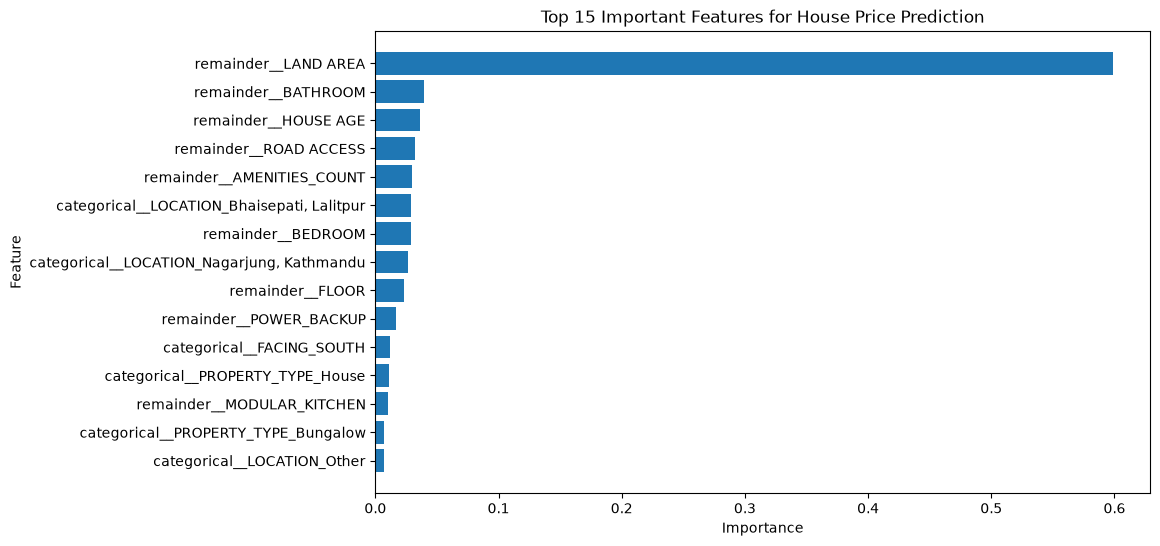

In [175]:


top_features = importance_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features for House Price Prediction")
plt.gca().invert_yaxis()

plt.show()

## GradientBoostingRegressor

In [176]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

In [177]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", gb_model)
])


In [178]:
gb_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['LOCATION','LAND AREA','ROAD ACCESS',...,'DINING_ROOM','POWER_BACKUP', 'AMENITIES_COUNT']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subs

In [179]:
gb_pred = gb_pipe.predict(X_test)

In [180]:
print("Gradient Boosting Results")
print("MAE:", mean_absolute_error(y_test, gb_pred))
print("R2 Score:", r2_score(y_test, gb_pred))

Gradient Boosting Results
MAE: 8664535.39879325
R2 Score: 0.5909369653857879


In [181]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred)
    ],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,R2 Score
2,Gradient Boosting,8.664535e+06,0.590937
1,Random Forest,8.986342e+06,0.514366
0,Linear Regression,1.112002e+07,0.320830
